In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


In [2]:
load_dotenv()
data_dir = Path(os.getenv('DATA_FILE_DIR'))
path2processed = data_dir /'log_processed.csv'

In [3]:
df = pd.read_csv(path2processed, parse_dates=['datetime'], dtype={'status_Code': 'Int64', 'lat': 'Float64', 'lon': 'Float64'})

In [4]:
df.head()

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
0,129.146.237.0,2026-07-12 11:11:43+00:00,GET,/blog/0,HTTP/1.1,200,Scrapy/2.16.0 (+https://scrapy.org),R,United States,US,AZ,Arizona,Phoenix,85008,33.4656,-111.9956,America/Phoenix
1,47.82.11.184,2026-07-12 11:12:43+00:00,GET,/robots.txt,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
3,40.77.167.144,2026-07-12 11:20:49+00:00,GET,/,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",R,United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
4,17.241.227.225,2026-07-12 11:26:03+00:00,GET,/photos/france,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,United States,US,CA,California,Cupertino,95014,37.3322,-122.011,America/Los_Angeles


In [5]:
groups = df.groupby('Agent_Type')

In [6]:
groups['ip_address'].count()

Agent_Type
H    1566
R    1473
Name: ip_address, dtype: int64

In [7]:
min_date = df['datetime'].min().strftime("%Y-%m-%d")
max_date = df['datetime'].max().strftime("%Y-%m-%d")

In [19]:
groups.get_group('H')

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
5,154.159.252.207,2026-07-12 12:02:19+00:00,GET,/photos/australia,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10) ...,H,Kenya,KE,30,Nairobi County,Nairobi,9831,-1.2841,36.8155,Africa/Nairobi
7,171.250.162.196,2026-07-12 12:35:37+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_3_1)...,H,Vietnam,VN,SG,Ho Chi Minh,Ho Chi Minh City,700000,10.822,106.6257,Asia/Ho_Chi_Minh
8,190.62.87.242,2026-07-12 13:21:14+00:00,GET,/blog/0,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,H,El Salvador,SV,SS,San Salvador Department,San Salvador,NaN,13.6927,-89.1917,America/El_Salvador
9,138.84.33.34,2026-07-12 14:59:35+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,H,Chile,CL,RM,Santiago Metropolitan,Santiago,NaN,-33.4488,-70.6692,America/Santiago
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3032,190.97.232.134,2026-08-09 16:57:32+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,H,Venezuela,VE,E,Barinas,Sabaneta,NaN,8.75234,-69.9335,America/Caracas
3033,14.134.19.150,2026-08-09 16:57:44+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_0_0)...,H,China,CN,NX,Ningxia,Yinchuan,750000,38.4712,106.259,Asia/Shanghai
3034,101.249.128.108,2026-08-09 16:58:21+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_6...,H,China,CN,XZ,Tibet,Jibenggang,NaN,29.6472,91.1174,Asia/Shanghai
3035,223.109.46.104,2026-08-09 16:58:29+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_0_0)...,H,China,CN,JS,Jiangsu,Nanjing,210000,32.0607,118.763,Asia/Shanghai


In [9]:
counts_human = groups.get_group('H').groupby('countryCode')['ip_address'].count().sort_values(ascending=False)

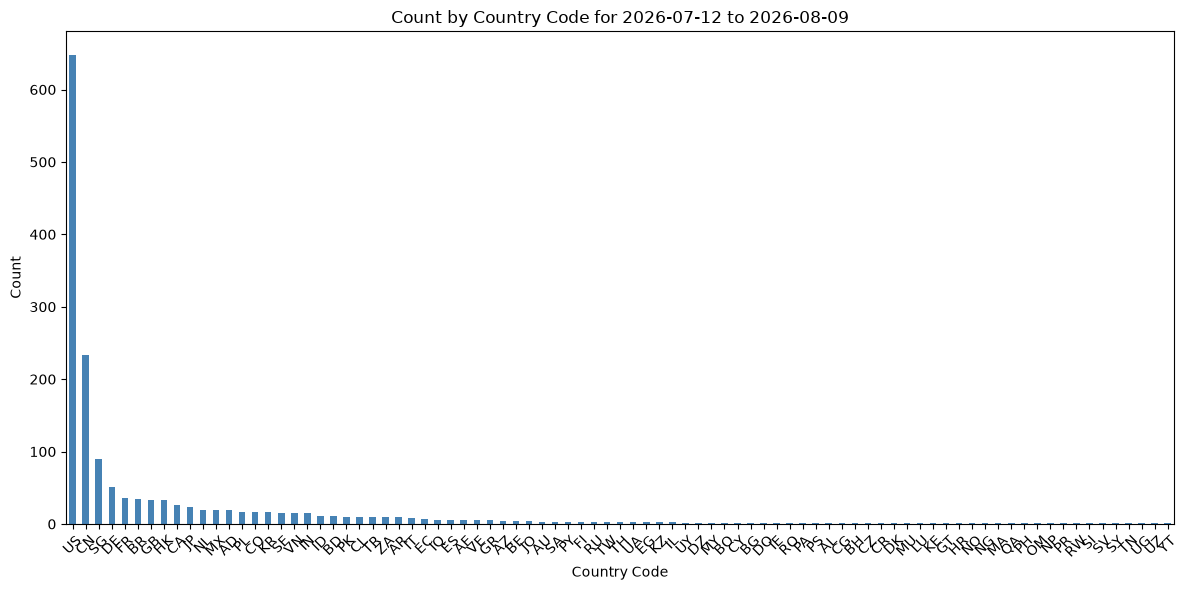

In [10]:

counts_human.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title(f'Count by Country Code for {min_date} to {max_date}')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
counts_human[:10]

countryCode
US    648
CN    234
SG     90
DE     51
FR     36
BR     35
GB     33
HK     33
CA     26
JP     24
Name: ip_address, dtype: int64

In [23]:
for key, value in counts_human.items():
    print(key, value)

US 648
CN 234
SG 90
DE 51
FR 36
BR 35
GB 33
HK 33
CA 26
JP 24
NL 20
MX 19
AD 19
PL 17
CO 16
KR 16
SE 15
VN 15
IN 15
ID 11
BD 11
PK 9
CL 9
TR 9
ZA 9
AR 9
IT 8
EC 7
IQ 6
ES 6
AE 6
VE 5
GR 5
AZ 4
BE 4
JO 4
AU 3
SA 3
PY 3
FI 3
RU 3
TW 3
TH 3
UA 3
EG 3
KZ 3
IL 3
UY 2
DZ 2
MY 2
BO 2
CY 2
BG 2
DO 2
IE 2
RO 2
PA 2
PS 2
AL 1
CG 1
BH 1
CZ 1
CR 1
DK 1
MU 1
LU 1
KE 1
GT 1
HR 1
NO 1
NG 1
MA 1
QA 1
PH 1
OM 1
NP 1
PR 1
RW 1
SI 1
SV 1
SY 1
TN 1
UG 1
UZ 1
YT 1


In [12]:
counts_endpoints = groups.get_group('H').groupby('endpoint')['ip_address'].count().sort_values(ascending=False)


In [30]:
endpoints = list(counts_endpoints[:10].to_dict().keys())
counts = list(counts_endpoints[:10].to_dict().values())
df_endpoints = pd.DataFrame({'endpoints': endpoints, 'counts': counts})
df_endpoints

,endpoints,counts
0,/blog/4,558
1,/blog/8,142
2,/,130
3,/blog/6,102
4,/blog,82
5,/blog/5,67
6,/blog/9,66
7,/aboutme,32
8,/login,25
9,/photos/australia,19


In [14]:
status_404 = groups.get_group('H').groupby('status_code').get_group(404)

In [15]:
status_404.groupby('endpoint')['ip_address'].count().sort_values(ascending=False)

endpoint
/.git/config                   5
/wp-json/wp/v2/users           3
/ads.txt                       2
/.git/HEAD                     2
/.env                          1
/admin/.git/config             1
/administrator/                1
/api/.git/config               1
/app/.git/config               1
/_ignition/execute-solution    1
/asset-manifest.json           1
/assets/manifest.json          1
/backend/.git/config           1
/backup/.git/config            1
/dev/.git/config               1
/dist/manifest.json            1
/git/.git/config               1
/application/.git/config       1
/mail/.git/config              1
/manifest.json                 1
/media/system/js/core.js       1
/media/jui/js/jquery.min.js    1
/sitemap-index.xml             1
/sitemap_news.xml.gz           1
/sites/favicon.ico             1
/public/.git/config            1
/staging/.git/config           1
/static/manifest.json          1
/webpack-stats.json            1
/v2/.git/config                1
/

In [47]:
daily_human = groups.get_group('H').groupby(pd.Grouper(key='datetime', freq='D'))
daily_robots = groups.get_group('R').groupby(pd.Grouper(key='datetime', freq='D'))


In [48]:
daily_human_visits = daily_human['ip_address'].count()
daily_robot_visits = daily_robots['ip_address'].count()

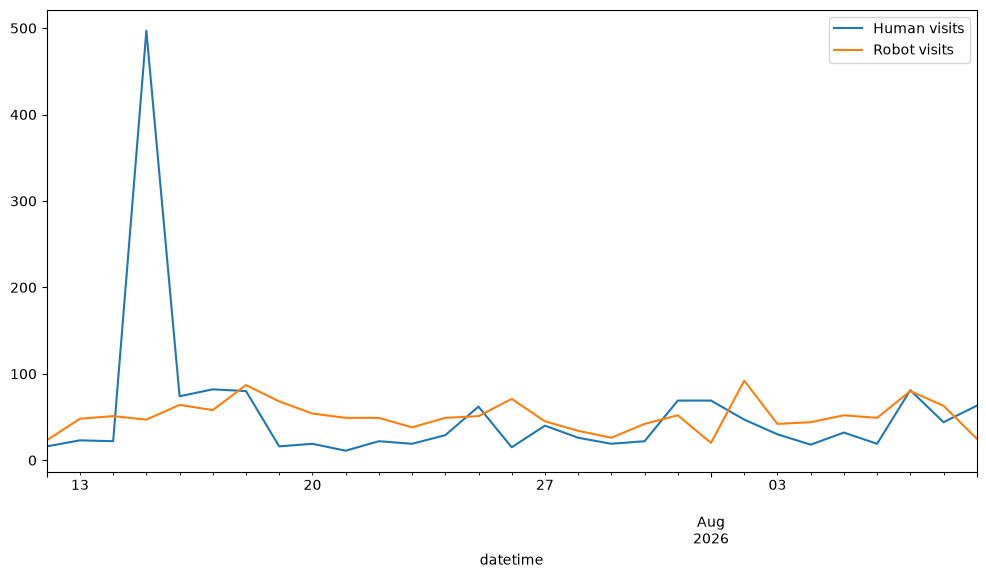

In [50]:
ax = daily_human_visits.plot(
    kind="line",
    figsize=(12, 6),
    label="Human visits",
)
daily_robot_visits.plot(
    kind="line",
    ax=ax,
    label="Robot visits",
)
ax.legend()